In [2]:
from typing import TypedDict, Sequence,Annotated, List, Literal
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel , Field
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.prebuilt import tools_condition
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END , START
from langgraph.prebuilt import ToolNode


In [3]:
api_key=groq_Api_key
llm=ChatGroq(model_name="llama-3.3-70b-versatile",api_key=api_key)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001F141A66210>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F141A67230>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [4]:
import time
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]
    topic:str=None
    task_state : str=''
    next_agent: str=''

In [5]:
# Create supervisor agent
def Supervisor_Agent(state:AgentState):
   
    task_state=state['task_state']
    message=state["messages"][-1].content
    question=state['topic']
    # return task_state,message,question
    

    supervisor_prompt = PromptTemplate(
            template= """ 
                You are an efficient supervisor that manages and delegates the study plan to other sub-agents based on user's input .
                The following are your team members:
                1. Planner:     Generates study plans based on topic, available time
                2. Retriever :	Fetch any online study materials for the topic mentioned
                3. Summarizer:  Summarizes entire study plan based on content
                4. Report:      Creates a full report of study plan with time breakdown for sections                

               A) **Based on the task_state , decide which agent should work next.**
                
                1. If the task_state is 'Start task' assign next agent as 'Planner'
                2. If the task_state is 'Planning Done' refer to section B.
                3. If the task_state is 'Retrieve Done' assign next agent as 'Summarizer'
                4. If the task_state is 'Summary Done' assign next agent as 'DONE'
                5. If the task_state is 'DONE' assign next agent as 'complete'
                6: If the task_state is empty or not clearly defined assign next agent as 'complete'


               B) ** As a supervisor you need to strictly follow the mentioned steps only if task_state = 'Planning Done':**

                1.Understand the user question correctly do not hallucinate any out of context meaning.
                2.Only if the user question asks for any extra study materials such as links , real time study materials , study resources in the question 
                  For example: 'Provide me with a study plan for Python in 2 hours . Also provide with study materials' , then delegate it to the Retriever which means assign next agent as 'Retriever'.
                3.If the user asks only for a simple study plan without any real time resources , study materials such as links , study resources
                  For example: 'Provide me with a study plan for Python in 2 hours' , assign next agent as 'Summarizer'.
                

                
                User Input
                - question : {question}
                
                Current state:
                - task_state : {task_state}
              

                Respond in strictly one word with ONLY the agent names 
                For Example:
                1. Planner / Summarizer / Retriever / Reminder / complete

                DO NOT provide thinking steps while responding to the question
            """,
            input_variables=["question","task_state"]
        
        )
    chain= supervisor_prompt | llm

    research_response=chain.invoke({"question":question,"task_state": task_state})
    
    agents=['Planner' , 'Summarizer' , 'Retriever' , 'complete']
    next=''
    # print(research_response.content)
    for x in agents:
        if (x in research_response.content):
            next=x


    if research_response.content == 'complete':
        print(f'Here is the fully curated plan for you  ')
        print(message)
        dict= {
            'messages': [message]+['Agent process is complete'],
            'topic':question,
            'next_agent': 'complete',
            'task_state': 'DONE'
        }
        # print(f'supervisor dict {dict}')
        return dict
        
    else:
        print(f'SUPERVISOR Delegates task to {next}')
        print(f'Agent {next} is Active Now .... ')

        dict= {
            'messages': [AIMessage(content=message)],
            'topic':question,
            'next_agent': next,
            'task_state': task_state
        }

        # print(f'supervisor dict {dict}')
        return dict

    


In [7]:
# res = Supervisor_Agent({
#     "messages": [
#         HumanMessage(content="Starting with the Process")
#     ],
#     "topic": "I want to study CI/CD in 2 hours along with study materials",
#     "next_agent": "supervisor",
#     "task_state": "Planning Done"
# })
# res


In [6]:
from langchain.chains import LLMChain
def Planner_agent(state:AgentState):
    print('Planner Agent here :) .. Curating the best plan for your requirement.... ')
    # print(state)
    task_state=state['task_state']
    message=state["messages"][-1].content
    question=state['topic']
    # return question , message , task_state 

    prompt = PromptTemplate(
    input_variables=["topic"],
    template=""" Provide a curated study plan for user's input {topic} 
                 Do not add any links , hyperlinks or any online resources just provide an overall study plan best to your knowledge.
                 Provide the plan in bulled points .
                 For example: 
                 1.
                 2.
                 3.  """
                    )

    
    plan_chain = LLMChain(
        llm=llm,
        prompt=prompt
    )
    response=plan_chain.invoke({"topic":question})
    

    dict={
        'messages': [message]+[AIMessage(content=response['text'])],
        'topic':question,
        'next_agent':'supervisor',
        'task_state': 'Planning Done'
    }

    # print(f'Plan : {response['text']}')
    return  dict



In [ ]:
# y=Planner_agent({'messages': [AIMessage(content='Starting with the Process', additional_kwargs={}, response_metadata={})],
#  'topic': 'I want to study Python Basics in 2 hours — provide a plan and useful links.',
#  'next_agent': 'Planner',
#  'task_state': 'Start task'})
# y

In [7]:
def retriever_tool(state: AgentState):

    print('Fetching some Real time study materials for you ....')
    # print(state)
    topic=state['topic']
    message=state["messages"]
    
    
    tavily_api_key= tavily_api_key
    
    search=TavilySearchResults(max_results=3,tavily_api_key=tavily_api_key)
    results=search.invoke(topic)
    details=[]
    
    for x in results:
        
        details.append(x['title'])
        details.append(x['url'])
        details.append(x['content'])
  
    
    # print(f'details | {details}')
    message=message[-1].content
    details=','.join(details)
    messages=message+details
    

    return {
        'messages': messages,
        'topic':topic ,
        'next_agent':'supervisor',
        'task_state': 'Retriving Done'
    }



In [8]:
def summarizer_agent(state:AgentState):
    print('Summarizing your complete plan....')
    
    
    message=state['messages']
    plan=state['messages'][-1].content
    # print(plan)
    
        
    question=state['topic']
    # return question , plan , task_state 
    

    prompt = PromptTemplate(
    input_variables=["plan"],
    template="""
            You are an expert summarizer agent that helps arrange and curate notes in a way that it is understandable by everyone.
            Your job is simple. Follow these steps:
            1. Understand the study plan provided here  {plan}
            2. Re - arrange and provide a summary of the plan into steps that is clear and concise.
            3. Do not change the context of the plan
            5. Respond with a proper bullet pointed output 
            For Example:
                1.
                2.
                3.
            6.If there are any study materials or links provided in the plan provide it separately in bullets
            For Example:
                Here are some study materials:
                1.
                2.  

 """
)
    summary_chain = LLMChain(
        llm=llm,
        prompt=prompt
    )
    # plan=plan + '\n' + tools
    response=summary_chain.invoke({"plan":plan})
    
    # print(response['plan'])

    

    return {
        'messages': message+[AIMessage(content=response['plan'])],
        'topic':question,
        'next_agent':'supervisor',
        'task_state': 'DONE'
    }
    



In [9]:
def router(state:AgentState) -> Literal["supervisor", "Planner", "Retriever","Summarizer", "__end__"]:
    next_agent=state['next_agent']

    
    if next_agent == 'complete' :
        return 'DONE'
    elif next_agent=='Planner' :
        return 'Plan'
    elif next_agent=='Retriever' :
        return 'Retrive'
    elif next_agent=='Summarizer' :
        return 'Summarize'

    
    return "supervisor"
    

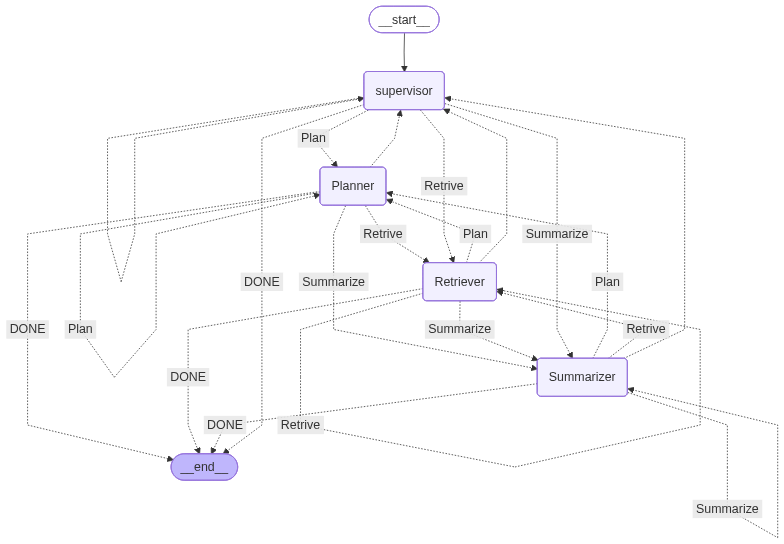

In [10]:
 #Build Graph
# Add nodes
workflow=StateGraph(AgentState)
workflow.add_node("supervisor",Supervisor_Agent)
workflow.add_node("Planner", Planner_agent) 
workflow.add_node("Retriever", retriever_tool) 
workflow.add_node("Summarizer", summarizer_agent)
workflow.set_entry_point("supervisor")


for node in [ "supervisor","Planner", "Retriever","Summarizer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "Plan": "Planner",
            "Retrive": "Retriever",
            "Summarize" : "Summarizer",
            'DONE': END
        }
    )

app=workflow.compile()


from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    
    pass


In [11]:
# res=app.invoke('I want to study Python Basics in 2 hours — provide a plan and useful links."')

def agent_run(qry):
    res = app.invoke({
        "messages": [
            HumanMessage(content="Starting with the Process")
        ],
        "topic": f"{qry}",
        "next_agent": "supervisor",
        "task_state": "Start task"
    })
    return res


result=agent_run('I want to study MLOPS Basics in 2 hours')


SUPERVISOR Delegates task to Planner
Agent Planner is Active Now .... 
Planner Agent here :) .. Curating the best plan for your requirement.... 


C:\Users\Bhakti Thakur\AppData\Local\Temp\ipykernel_80292\1468885147.py:22: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  plan_chain = LLMChain(


SUPERVISOR Delegates task to Summarizer
Agent Summarizer is Active Now .... 
Summarizing your complete plan....
Here is the fully curated plan for you  
Here's a curated 2-hour study plan for MLOPS Basics:
* Introduction to MLOPS (10 minutes): Start by understanding what MLOPS is, its importance, and how it helps in streamlining machine learning workflows.
* Key Concepts in MLOPS (20 minutes): Study the fundamental concepts of MLOPS, including data ingestion, data preprocessing, model training, model deployment, and model monitoring.
* MLOPS Lifecycle (20 minutes): Learn about the different stages of the MLOPS lifecycle, including data preparation, model development, model testing, model deployment, and model maintenance.
* MLOPS Tools and Technologies (30 minutes): Familiarize yourself with popular MLOPS tools and technologies, such as TensorFlow, PyTorch, Scikit-learn, and Kubernetes, and understand their roles in the MLOPS ecosystem.
* MLOPS Best Practices (20 minutes): Study the be

In [12]:
def agent_run(qry):
    res = app.invoke({
        "messages": [
            HumanMessage(content="Starting with the Process")
        ],
        "topic": f"{qry}",
        "next_agent": "supervisor",
        "task_state": "Start task"
    })
    return res


result=agent_run('I want to study MLOPS Basics in 2 hours provide with study materials and links')

SUPERVISOR Delegates task to Planner
Agent Planner is Active Now .... 
Planner Agent here :) .. Curating the best plan for your requirement.... 
SUPERVISOR Delegates task to Retriever
Agent Retriever is Active Now .... 
Fetching some Real time study materials for you ....


C:\Users\Bhakti Thakur\AppData\Local\Temp\ipykernel_80292\578051999.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search=TavilySearchResults(max_results=3,tavily_api_key=tavily_api_key)


SUPERVISOR Delegates task to Summarizer
Agent Summarizer is Active Now .... 
Summarizing your complete plan....
Here is the fully curated plan for you  
Here's a curated study plan for MLOPS Basics in 2 hours:
* Introduction to MLOPS (10 minutes): Understand the basics of MLOPS, its importance, and how it helps in streamlining machine learning workflows
* Key Concepts in MLOPS (20 minutes): Study the key concepts such as model versioning, data versioning, model serving, and monitoring
* MLOPS Workflow (20 minutes): Learn about the different stages of the MLOPS workflow, including data preparation, model training, model deployment, and model monitoring
* MLOPS Tools and Techniques (30 minutes): Familiarize yourself with popular MLOPS tools such as docker, kubernetes, and jenkins, and understand how they are used in MLOPS
* Model Deployment and Serving (20 minutes): Study how to deploy and serve machine learning models using MLOPS, including model serialization, containerization, and orc

In [13]:
def agent_run(qry):
    res = app.invoke({
        "messages": [
            HumanMessage(content="Starting with the Process")
        ],
        "topic": f"{qry}",
        "next_agent": "supervisor",
        "task_state": "Start task"
    })
    return res


result=agent_run('Curate me a concise study plan to learn Agentic AI in 3 days')

SUPERVISOR Delegates task to Planner
Agent Planner is Active Now .... 
Planner Agent here :) .. Curating the best plan for your requirement.... 
SUPERVISOR Delegates task to Summarizer
Agent Summarizer is Active Now .... 
Summarizing your complete plan....
Here is the fully curated plan for you  
Here is a curated study plan to learn Agentic AI in 3 days:
* Day 1: 
  * Introduction to Agentic AI: understand the concept of agentic AI, its definition, and how it differs from other types of AI
  * Agents and Environments: learn about the components of agentic AI, including agents, environments, and their interactions
  * Types of Agents: study the different types of agents, such as simple reflex agents, model-based reflex agents, and goal-based agents
  * Agent Architectures: understand the various agent architectures, including reactive, deliberative, and hybrid architectures
* Day 2: 
  * Perception and Action: learn about how agents perceive their environment and take actions
  * State

In [14]:
def agent_run(qry):
    res = app.invoke({
        "messages": [
            HumanMessage(content="Starting with the Process")
        ],
        "topic": f"{qry}",
        "next_agent": "supervisor",
        "task_state": "Start task"
    })
    return res


result=agent_run('Curate me a concise study plan to learn Agentic AI in 3 days . Also provide with relevant study materials')

SUPERVISOR Delegates task to Planner
Agent Planner is Active Now .... 
Planner Agent here :) .. Curating the best plan for your requirement.... 
SUPERVISOR Delegates task to Retriever
Agent Retriever is Active Now .... 
Fetching some Real time study materials for you ....
SUPERVISOR Delegates task to Summarizer
Agent Summarizer is Active Now .... 
Summarizing your complete plan....
Here is the fully curated plan for you  
Here's a 3-day study plan to learn Agentic AI:

* Day 1: Introduction to Agentic AI and Foundations
  * Start by understanding the basics of Agentic AI, its definition, and applications
  * Study the core concepts of agency, autonomy, and decision-making in AI systems
  * Learn about the different types of Agentic AI, such as reactive, proactive, and adaptive agents
  * Familiarize yourself with the key technologies used in Agentic AI, including machine learning, natural language processing, and computer vision
  * Read chapters or sections on Agentic AI from textbook